In [21]:
import pandas as pd
import SimpleITK as sitk
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import ast

In [2]:
df_pre_data = pd.read_csv(r'preprocessing_log.csv')

In [17]:
df_pre_data[df_pre_data['status']=='Failed'].to_csv('failed_preprocessing_temp.csv', index=False)

In [10]:
df_pre_data.dtypes

SeriesInstanceUID    object
status               object
shape_z_y_x          object
error                object
dtype: object

In [26]:
df_pre_data_suc = df_pre_data[df_pre_data['status']=='Success'].copy()

In [19]:
df_pre_data_suc.shape

(1794, 4)

In [20]:
df_pre_data_suc

,SeriesInstanceUID,status,shape_z_y_x,error
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,Success,"(86, 299, 253)",NaN
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,Success,"(163, 297, 234)",NaN
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,Success,"(124, 314, 240)",NaN
3,1.2.826.0.1.3680043.8.498.10022796280698534221...,Success,"(8, 45, 65)",NaN
4,1.2.826.0.1.3680043.8.498.10030095840917973694...,Success,"(106, 174, 240)",NaN
...,...,...,...,...
1852,1.2.826.0.1.3680043.8.498.99887675554378211308...,Success,"(44, 153, 58)",NaN
1853,1.2.826.0.1.3680043.8.498.99892390884723813599...,Success,"(128, 305, 251)",NaN
1854,1.2.826.0.1.3680043.8.498.99895756899933461331...,Success,"(25, 62, 58)",NaN
1855,1.2.826.0.1.3680043.8.498.99953513260518059135...,Success,"(18, 117, 75)",NaN


In [ ]:
df_pre_data_suc['shape_z_y_x'] = df_pre_data_suc['shape_z_y_x'].apply(ast.literal_eval)

In [ ]:
def find_area(x):
    x,y,z= x
    return x*y*z

In [ ]:
df_pre_data_suc['area'] = df_pre_data_suc['shape_z_y_x'].apply(find_area)

<Axes: xlabel='area'>

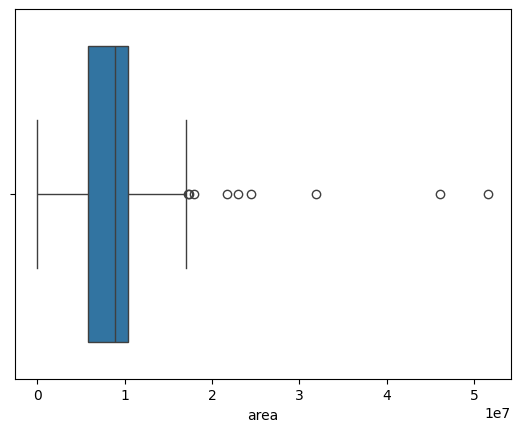

In [45]:
sns.boxplot(x=df_pre_data_suc['area'])